# Last-layer representation — what the network learned

Loads a trained DQN's saved weights and reads the **penultimate-layer activation** for every
canonical decision cell (the learned representation the Q head sees), then projects it to 2D.

The input space is already 2-3 interpretable dimensions (the basic-strategy heatmap plots it
exactly) — so this is *not* re-deriving that. It shows the **learned feature geometry**: where the
shared-weight representation separates the actions, and — the point — where the genuine errors
live. If the `genuine_disagreement` cells sit in one confusable region, that's the
function-approximation floor made visible (CONCEPTS §18, §26).

**PCA is primary** (deterministic, robust at N=240). **t-SNE is a secondary cross-check** only
(small N → layout is perplexity-sensitive; don't over-read clusters).

Needs `scikit-learn` and `matplotlib`.

In [ ]:
import sys
from pathlib import Path
import numpy as np

# locate the blackjack-rl root (the dir containing the blackjack_rl package) and the latest run
here = Path.cwd()
ROOT = next(p for p in [here, *here.parents] if (p / 'blackjack_rl').is_dir())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from blackjack_rl.evaluation.embedding import load_agent, cell_embeddings

runs = sorted((ROOT / 'runs').glob('*/model.pt'), key=lambda f: f.stat().st_mtime)
RUN = runs[-1].parent            # newest run; set manually to compare a specific one
agent = load_agent(RUN)
ce = cell_embeddings(agent)
X = np.array(ce.embeddings)      # [240, hidden_last]
cells = ce.cells
print('run        :', RUN.name)
print('embeddings :', X.shape)

run        : 20260621-183115_seed42_5f41c7a
embeddings : (240, 64)


## PCA — the primary view

Three colorings of the same 2D projection: chosen **action**, diff **category** (the key panel —
do the errors cluster?), and **decision margin** `Q(best) - Q(2nd)` (the net's own confidence —
low margin traces the decision boundaries).

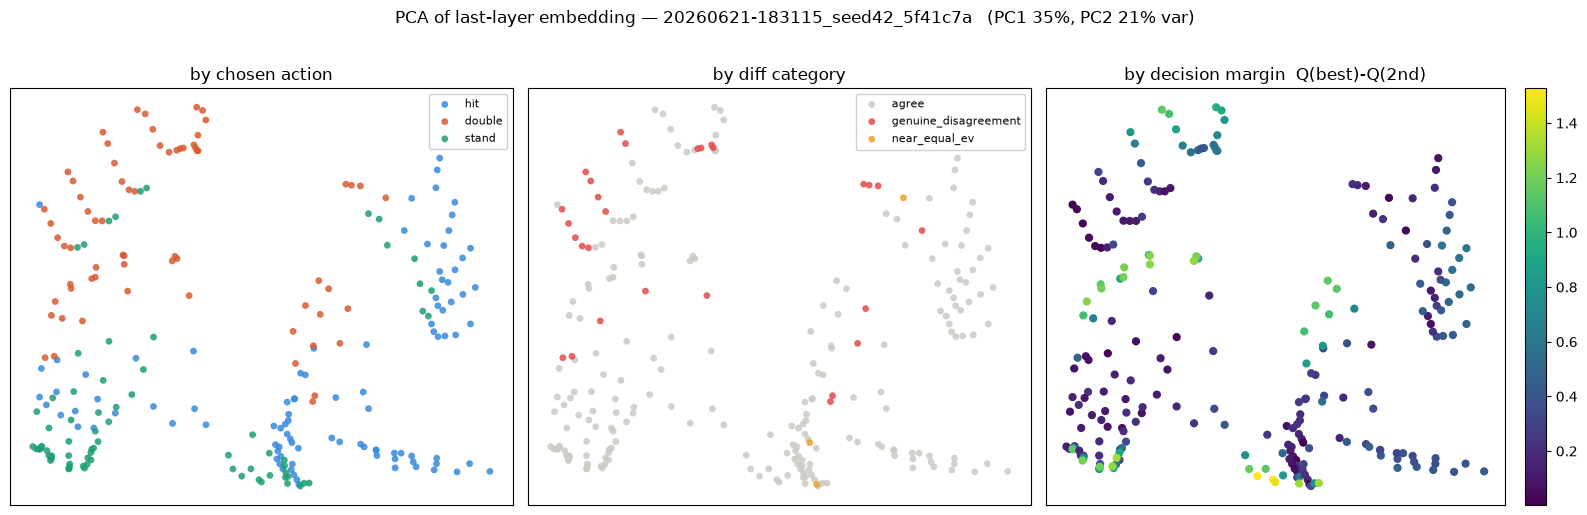

In [10]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
Y = pca.fit_transform(X)
evr = pca.explained_variance_ratio_

ACT = {'hit': '#378ADD', 'stand': '#1D9E75', 'double': '#D85A30', 'split': '#7F77DD'}
CAT = {'agree': '#CBCBC4', 'near_equal_ev': '#EF9F27',
       'genuine_disagreement': '#E24B4A', 'under_visited': '#888888'}

def scatter_cat(ax, pts, labels, colors, title):
    for lab in dict.fromkeys(labels):
        m = [i for i, l in enumerate(labels) if l == lab]
        ax.scatter(pts[m, 0], pts[m, 1], s=24, c=colors.get(lab, '#888888'),
                   label=str(lab), edgecolor='none', alpha=0.85)
    ax.set_title(title); ax.set_xticks([]); ax.set_yticks([])
    ax.legend(fontsize=8, framealpha=0.9)

fig, ax = plt.subplots(1, 3, figsize=(16, 5))
scatter_cat(ax[0], Y, [c['action'] for c in cells], ACT, 'by chosen action')
scatter_cat(ax[1], Y, [c['category'] for c in cells], CAT, 'by diff category')
sc = ax[2].scatter(Y[:, 0], Y[:, 1], s=24, c=[c['q_margin'] for c in cells], cmap='viridis')
ax[2].set_title('by decision margin  Q(best)-Q(2nd)'); ax[2].set_xticks([]); ax[2].set_yticks([])
fig.colorbar(sc, ax=ax[2], fraction=0.046, pad=0.04)
fig.suptitle(f'PCA of last-layer embedding — {RUN.name}   '
             f'(PC1 {evr[0]:.0%}, PC2 {evr[1]:.0%} var)', y=1.02)
plt.tight_layout(); plt.show()

## Does it actually cluster by action? (a number, not a vibe)

Silhouette score of the action labels in the **full** embedding space — robust to the 2D
projection. Higher = same-action cells are tighter and better separated from other actions.

In [11]:
from sklearn.metrics import silhouette_score
from collections import Counter

act = [c['action'] for c in cells]
code = {a: i for i, a in enumerate(dict.fromkeys(act))}
sil = silhouette_score(X, [code[a] for a in act])
print(f'action silhouette (embedding space): {sil:+.3f}   (->1 clean clusters, ~0 overlapping)')
print('action   counts:', dict(Counter(act)))
print('category counts:', dict(Counter(c['category'] for c in cells)))

action silhouette (embedding space): +0.178   (->1 clean clusters, ~0 overlapping)
action   counts: {'hit': 98, 'double': 67, 'stand': 75}
category counts: {'agree': 209, 'genuine_disagreement': 28, 'near_equal_ev': 3}


## t-SNE — secondary cross-check only

Nonlinear view. With N=240 the layout is sensitive to `perplexity`; treat agreement with the PCA
story as confirmation, not the clusters themselves as truth.

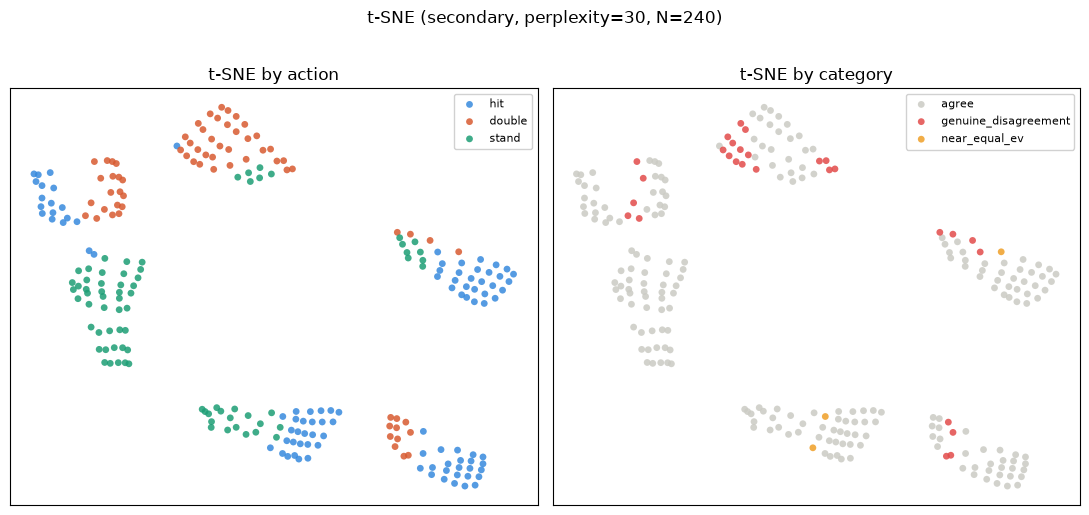

In [12]:
from sklearn.manifold import TSNE

perp = 30
T = TSNE(n_components=2, perplexity=perp, init='pca', random_state=0).fit_transform(X)
fig, ax = plt.subplots(1, 2, figsize=(11, 5))
scatter_cat(ax[0], T, [c['action'] for c in cells], ACT, 't-SNE by action')
scatter_cat(ax[1], T, [c['category'] for c in cells], CAT, 't-SNE by category')
fig.suptitle(f't-SNE (secondary, perplexity={perp}, N={len(cells)})', y=1.02)
plt.tight_layout(); plt.show()

## How to read it

- **action panel** — clean action regions = the representation learned a sensible decomposition.
- **category panel (the one that matters)** — if `genuine_disagreement` (red) clusters in a
  confusable zone where action regions touch, that's the function-approximation floor: the errors
  live where the shared weights can't separate the actions.
- **margin panel** — the low-margin band should trace the boundaries and overlap the near-ties.

This run is undertrained (a pipeline test); the real figures come from the long run — just re-run,
it auto-loads the newest `model.pt`.